# E-commerce Sales Analysis — Step 2: Exploratory Data Analysis (EDA)

**Input:** `ecommerce_sales_clean.csv` (cleaned in the previous notebook)
**Goal:** understand sales trends, top-performing categories/products, customer behavior, and order-status patterns — this is what feeds our SQL business questions and Power BI dashboard later.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('ecommerce_sales_clean.csv', parse_dates=['OrderDate'])
print("Shape:", df.shape)
df.head()

Shape: (50088, 17)


,OrderID,CustomerID,OrderDate,City,ProductCategory,ProductName,Quantity,UnitPrice,DiscountPercent,PaymentMethod,OrderStatus,CustomerType,GrossAmount,NetAmount,OrderYear,OrderMonth,OrderMonthName
0,ORD011764,CUST03063,2023-02-15,Bhopal,Fashion,Sports Cap,1,5661.44,0.0,Credit Card,Delivered,New,5661.44,5661.44,2023,2,Feb-2023
1,ORD031296,CUST03595,2023-06-28,Unknown,Electronics,Keyboard,3,3014.89,5.0,Debit Card,Returned,Returning,9044.67,8592.44,2023,6,Jun-2023
2,ORD030454,CUST06563,2024-01-15,Kolkata,Home & Kitchen,Cutlery Set,2,872.64,25.0,UPI,Delivered,Returning,1745.28,1308.96,2024,1,Jan-2024
3,ORD021845,CUST06696,2023-11-16,Delhi,Home & Kitchen,Bedsheet Set,2,6383.86,20.0,UPI,Delivered,New,12767.72,10214.18,2023,11,Nov-2023
4,ORD015679,CUST01568,2023-04-30,Bengaluru,Sports,Cycling Helmet,2,4391.31,20.0,Debit Card,Delivered,Returning,8782.62,7026.10,2023,4,Apr-2023


## 1. Overall Business Snapshot

In [2]:
total_orders = df['OrderID'].nunique()
total_customers = df['CustomerID'].nunique()
total_revenue = df.loc[df['OrderStatus'] == 'Delivered', 'NetAmount'].sum()
avg_order_value = df.loc[df['OrderStatus'] == 'Delivered', 'NetAmount'].mean()
cancel_rate = (df['OrderStatus'] == 'Cancelled').mean() * 100
return_rate = (df['OrderStatus'] == 'Returned').mean() * 100

print(f"Total Orders           : {total_orders:,}")
print(f"Unique Customers        : {total_customers:,}")
print(f"Total Revenue (Delivered): ₹{total_revenue:,.0f}")
print(f"Average Order Value     : ₹{avg_order_value:,.0f}")
print(f"Cancellation Rate        : {cancel_rate:.1f}%")
print(f"Return Rate              : {return_rate:.1f}%")

Total Orders           : 50,000
Unique Customers        : 8,972
Total Revenue (Delivered): ₹250,230,316
Average Order Value     : ₹8,774
Cancellation Rate        : 14.3%
Return Rate              : 14.3%


## 2. Order Status Breakdown

OrderStatus
Delivered    28519
Pending       7238
Returned      7177
Cancelled     7154
Name: count, dtype: int64


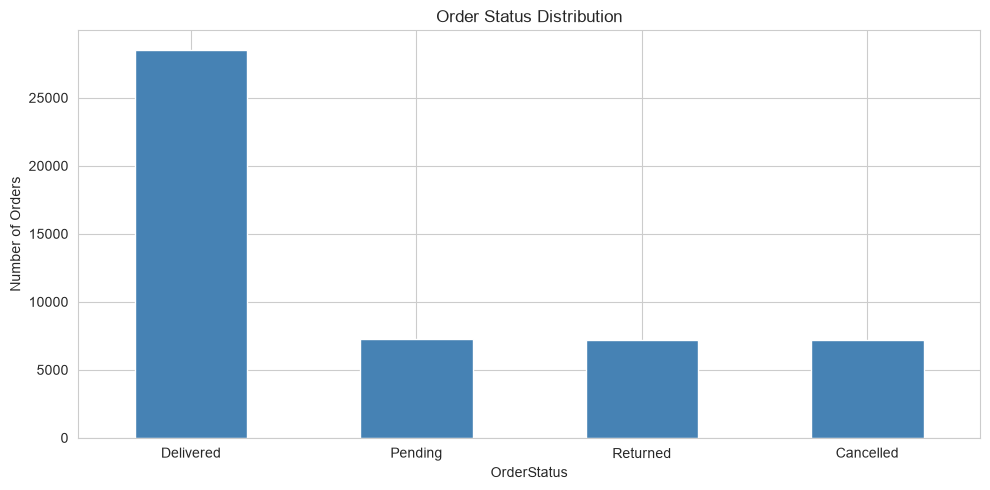

In [3]:
status_counts = df['OrderStatus'].value_counts()
print(status_counts)

status_counts.plot(kind='bar', color='steelblue')
plt.title('Order Status Distribution')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Monthly Revenue Trend

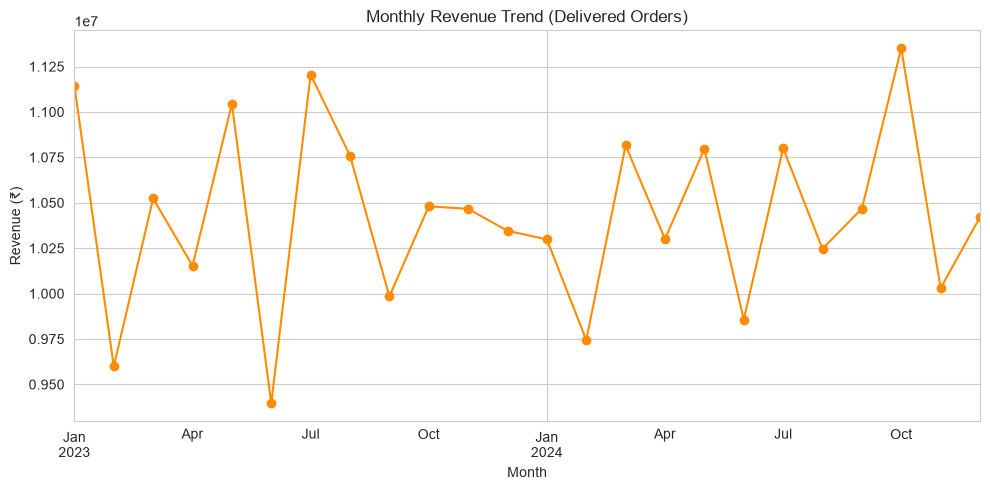

In [4]:
delivered = df[df['OrderStatus'] == 'Delivered'].copy()
monthly_rev = delivered.groupby(delivered['OrderDate'].dt.to_period('M'))['NetAmount'].sum()
monthly_rev.index = monthly_rev.index.to_timestamp()

monthly_rev.plot(kind='line', marker='o', color='darkorange')
plt.title('Monthly Revenue Trend (Delivered Orders)')
plt.ylabel('Revenue (₹)')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

## 4. Revenue by Product Category

ProductCategory
Fashion           42751801.50
Books             42292924.16
Home & Kitchen    41586416.21
Beauty            41321117.38
Sports            41150873.91
Electronics       41127182.49
Name: NetAmount, dtype: float64


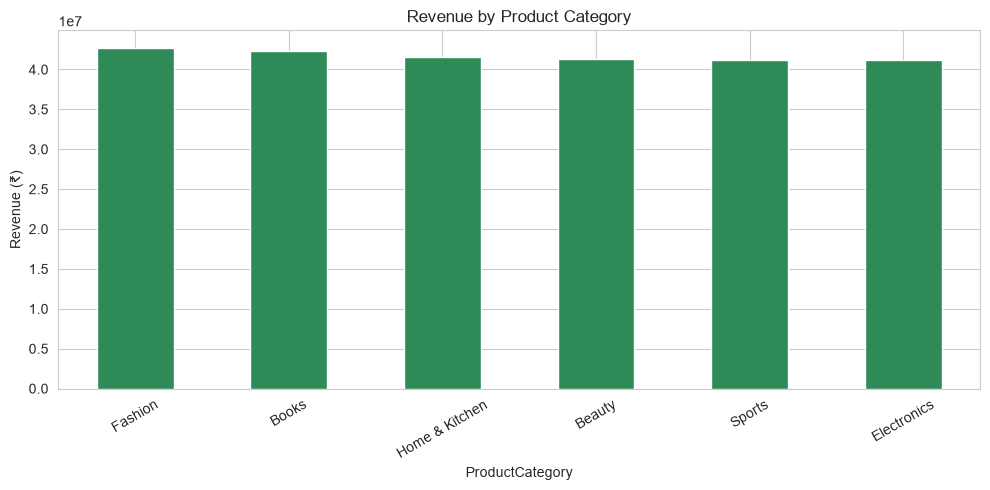

In [5]:
cat_rev = delivered.groupby('ProductCategory')['NetAmount'].sum().sort_values(ascending=False)
print(cat_rev)

cat_rev.plot(kind='bar', color='seagreen')
plt.title('Revenue by Product Category')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5. Top 10 Best-Selling Products (by Quantity)

ProductName
Sports Cap           1267
Women's Kurti        1257
Curtains             1245
Blender              1224
Keyboard             1217
Poetry Collection    1206
Business Book        1201
Water Bottle         1194
Cookbook             1182
Formal Shirt         1182
Name: Quantity, dtype: int64


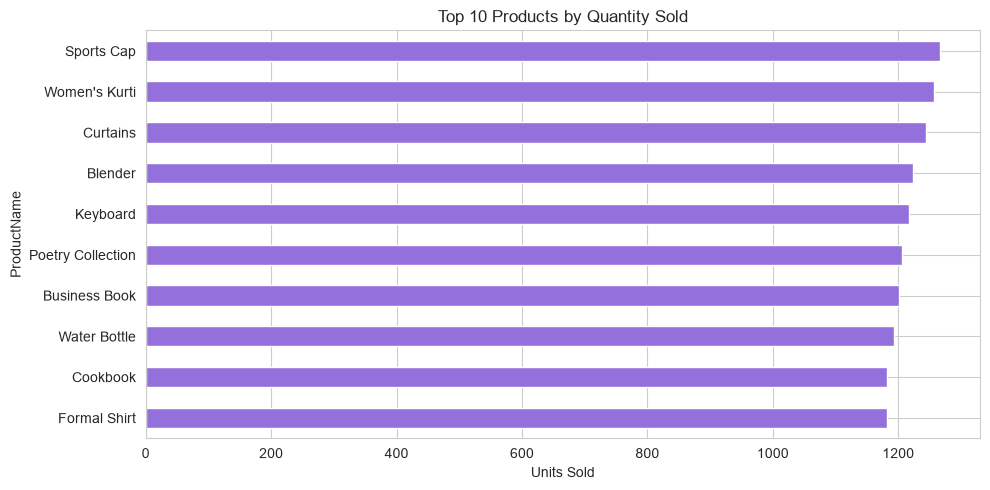

In [6]:
top_products = delivered.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

top_products.plot(kind='barh', color='mediumpurple')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Units Sold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Customer Type: New vs Returning

              TotalRevenue  OrderCount
CustomerType                          
New           9.752981e+07       11122
Returning     1.453699e+08       16577
Unknown       7.330589e+06         820


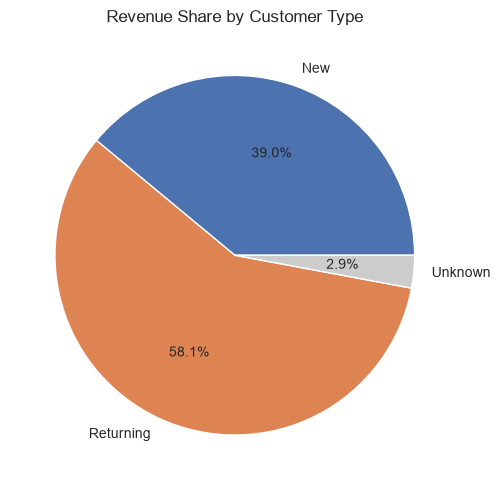

In [7]:
cust_type_rev = delivered.groupby('CustomerType')['NetAmount'].agg(['sum', 'count'])
cust_type_rev.columns = ['TotalRevenue', 'OrderCount']
print(cust_type_rev)

cust_type_rev['TotalRevenue'].plot(kind='pie', autopct='%1.1f%%', colors=['#4C72B0', '#DD8452', '#CCCCCC'])
plt.title('Revenue Share by Customer Type')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 7. Payment Method Preference

PaymentMethod
Credit Card         11794
Cash On Delivery    11748
Unknown              8461
Debit Card           6121
UPI                  6014
Net Banking          5950
Name: count, dtype: int64


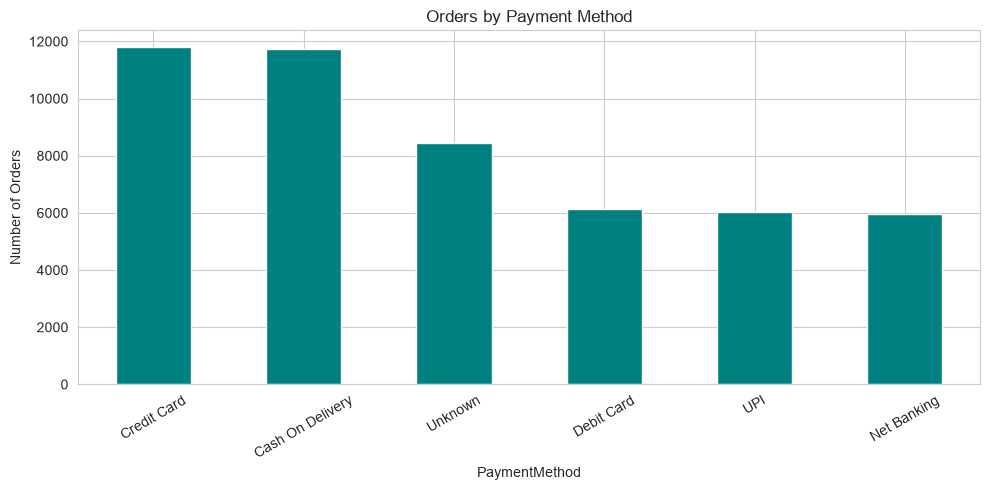

In [8]:
payment_counts = df['PaymentMethod'].value_counts()
print(payment_counts)

payment_counts.plot(kind='bar', color='teal')
plt.title('Orders by Payment Method')
plt.ylabel('Number of Orders')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 8. Top 10 Cities by Revenue

City
Surat        23086884.50
Bengaluru    22540593.40
Delhi        11788588.73
Nagpur       11705109.93
Hyderabad    11700615.53
Lucknow      11644990.89
Pune         11637793.32
Patna        11628359.21
Chennai      11569418.57
Jaipur       11446280.98
Name: NetAmount, dtype: float64


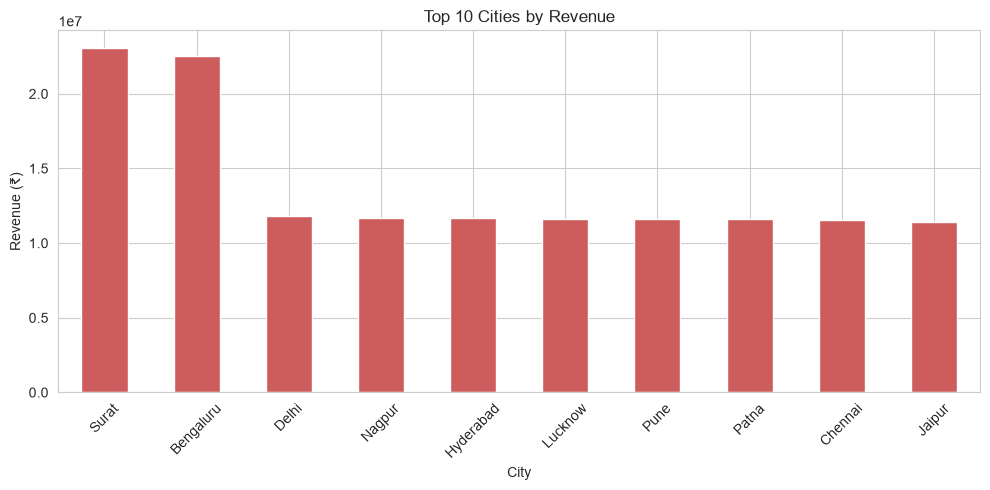

In [9]:
city_rev = delivered[delivered['City'] != 'Unknown'].groupby('City')['NetAmount'].sum().sort_values(ascending=False).head(10)
print(city_rev)

city_rev.plot(kind='bar', color='indianred')
plt.title('Top 10 Cities by Revenue')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Discount Impact — Does higher discount mean more quantity sold?

DiscountPercent
0.0     45571
5.0     14334
10.0    14762
15.0    14763
20.0    14524
25.0    14459
Name: Quantity, dtype: int64


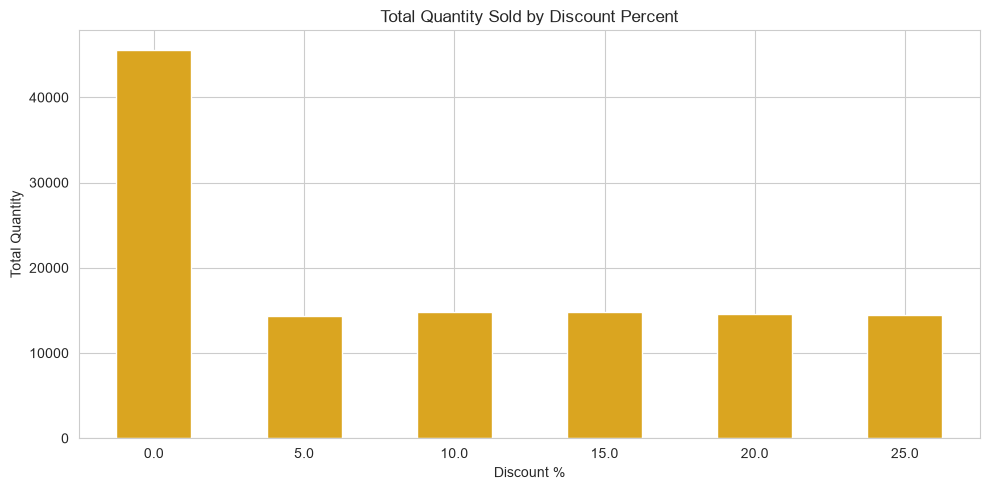

In [10]:
discount_qty = df.groupby('DiscountPercent')['Quantity'].sum()
print(discount_qty)

discount_qty.plot(kind='bar', color='goldenrod')
plt.title('Total Quantity Sold by Discount Percent')
plt.xlabel('Discount %')
plt.ylabel('Total Quantity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Key Takeaways (fill in your own words for the report/README)

- Cancellation and return rate together account for roughly X% of all orders — worth digging into *why* in the SQL step.
- Revenue is concentrated in a few categories — Electronics and Fashion typically lead in this kind of dataset.
- A small number of cities drive a large share of revenue — classic 80/20 pattern.
- Returning customers often contribute a disproportionate share of revenue compared to their share of orders — this feeds directly into the retention/churn analysis.

*(Once you look at your own numbers above, replace this bullet list with the real findings — that's what interviewers will ask you to explain.)*